In [1]:
# 1. TypedDict 으로 데이터 타입에 맞는 값 만들기
from typing import TypedDict

class User(TypedDict):
    id: int # 사용자 아이디: 정수
    name: str # 사용자 이름: 문자열
    email: str # 사용자 이메일: 문자열

user1:User = { # user1 변수의 데이터 타입을 User 클래스로 지정
    'id': 1,
    'name': 'tom',
    'email': 'test@naver.com'
}

print(user1)


{'id': 1, 'name': 'tom', 'email': 'test@naver.com'}


In [2]:
# 타입과 다른 value 입력 --> TypedDic는 타입힌트라서 실행시 오류는 발생하지 않음
user2:User = { # user1 변수의 데이터 타입을 User 클래스로 지정
    'id': 2,
    'name': 123,
    'email': 'test@naver.com'
}

print(user2)

{'id': 2, 'name': 123, 'email': 'test@naver.com'}


In [ ]:
# 2. BaseModel: 1) 타입 지정 2) 강제성이 있음 -> 다른 타입의 값을 입력하면 실행시 오류 발생
from pydantic import BaseModel

class User(BaseModel): # 파이단틱의 BaseModel 을 상속받아 정의한 User 클래스
    id: int # 사용자 아이디: 정수
    name: str # 사용자 이름: 문자열
    email: str # 사용자 이메일: 문자열

user_data: dict = {
    'id': 1,
    'name': 'tom',
    'email': 'test@naver.com'
}

# 딕셔너리 형태의 user_data를 언패킹(**) 하여 User 객체를 생성하면
# 타입 검증을 거친 뒤 모델 인스턴스가 생성.
user1 = User(**user_data)
print(user1)

id=1 name='tom' email='test@naver.com'


In [7]:
# 데이터 타입에 맞지 않는 값 넣어보기
user_data: dict = {
    'id': 1,
    'name': 123,
    'email': 'test@naver.com'
}
user2 = User(**user_data)
print(user2)

ValidationError: 1 validation error for User
name
  Input should be a valid string [type=string_type, input_value=123, input_type=int]
    For further information visit https://errors.pydantic.dev/2.13/v/string_type

In [9]:
# 기존 메시지에서 추가 메시지를 병합하는 데 사용하는 리듀서 함수 'add'를 추가한 예시.
from typing import TypedDict, Annotated

def add(left:list[str], right:list[str]) -> list[str]:
    return left + right

class State(TypedDict):
    messages: Annotated[list[str],add]
    # message는 list[str] 타입이며, 여러 값이 동시에 들어오면 add 함수를 이용해서 합쳐라



In [11]:
# 랭그래프에서는 에이전트로 들어온 메시지를 누적 저장하기 위해 리듀서 함수인 add_messages를 제공
# 이 함수는 기존 메시지에 새로운 메시지를 추가할 때 사용되며, 기본적으로 두 가지 입력을 받음.
# 첫 째는 기준이 되는 메시지 목록(또는 단일 메시지), 둘째는 여기에 추가할 메시지 목록(또는 단일 메시지)
from langgraph.graph.message import add_messages
from langchain_core.messages import AIMessage, HumanMessage

msg1 = [HumanMessage(content="hello", id="1")]
msg2 = [HumanMessage(content="hi, may i help you", id="2")]

add_messages(msg1, msg2)

[HumanMessage(content='hello', additional_kwargs={}, response_metadata={}, id='1'),
 HumanMessage(content='hi, may i help you', additional_kwargs={}, response_metadata={}, id='2')]

In [ ]:
# 각 메시지는 id를 가지고, 서로 동일한 id를 갖는 경우 기존 메시지에 새로운 메시지가 덮어쓰인 형태로 반환.
msg1 = [HumanMessage(content="hello", id="1")]
msg2 = [HumanMessage(content="hi, may i help you", id="1")]

add_messages(msg1, msg2) #앞에가 기존 메시지, 뒤가 새로운 메시지. 뒤에 메시지가 살아남는다.

[HumanMessage(content='hi, may i help you', additional_kwargs={}, response_metadata={}, id='1')]

In [15]:
from langchain_core.messages import AnyMessage

class State(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]

In [17]:
# 그래프 상태(State)에 답변 결과를 반환하기
from typing import TypedDict, Annotated
from operator import add
from langgraph.graph import StateGraph

# State 선언
class State(TypedDict):
    messages: Annotated[list[str], add]

# 그래프 객체 생성
graph = StateGraph(State)

    
# 노드 만들기
def chatbot(state: State):
    # 사용자 질문을 가져와서 LLM 에게 응답을 받음
    question = state['messages']
    answer = f"사용자 입력을 그대로 반환하는 챗봇입니다. {question}라는 질문을 받았습니다."
    return {'messages': [answer]}

graph.add_node('chatbot', chatbot) # 구현한 노드를 추가 # (노드의 이름, 노드를 구현한 함수) -> 보통 같은 이름을 사용 

In [18]:
# 시작점과 종료점 엣지 연결하기
from langgraph.graph import START, END

graph.add_edge(START, "chatbot")
graph.add_edge("chatbot", END) #graph


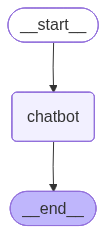

In [19]:
test = graph.compile()
test

In [ ]:
def routing_function(state: State) -> bool:
    if len(state["messages"][-1]) > 1000: # 제일 마지막 메시지, 최근 메시지가 1000자가 넘는지
        return True
    return False

# 파라미터로 보낸 라우팅 함수(routing_function)의 반환값(True, False)에 따라
graph.add_conditional_edges(
    "chatbot",
    routing_function,
    {True: "summary", False: END}
)

Adding an edge to a graph that has already been compiled. This will not be reflected in the compiled graph.
